## 1 — World Setup

This uses the same apartment world, symbol scope, and pickup-action schema as `full_pipe.ipynb`.
ROS publishers are omitted here because the notebook focuses on `sg_model` construction and EQL queries.

In [1]:
from pathlib import Path
from pprint import pprint

from dotenv import load_dotenv
from semantic_digital_twin.world_description.world_entity import Body
from uniworld import load_pr2_apartment_world

from llmr.reasoning.llm_provider import LLMProvider, make_llm

world, robot_view, context = load_pr2_apartment_world()
context.evaluate_conditions = False
symbol_type = Body

for candidate in (
    Path('llmr/.env'),
    Path('.env'),
    Path('../.env'),
    Path('../../../.env'),
):
    if candidate.exists():
        load_dotenv(candidate)
        break

import os
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', '')

llm = make_llm(LLMProvider.OPENAI, model='gpt-4o-mini', temperature=0.0)
print('LLM ready:', getattr(llm, 'model_name', llm))

`polytope` failed to import `cvxopt.glpk`.
will use `scipy.optimize.linprog`
Unknown attribute "type" in /robot[@name='pr2']/link[@name='base_laser_link']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='wide_stereo_optical_frame']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='narrow_stereo_optical_frame']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='laser_tilt_link']
Unknown tag "material" in /robot[@name='pr2']/link[@name='l_force_torque_link']/collision[1]
Unknown tag "material" in /robot[@name='apartment']/link[@name='coffe_machine']/collision[1]


LLM ready: gpt-4o-mini


In [2]:
# ROS setup
import rclpy
rclpy.init()
_ros_node = rclpy.create_node('semantic_digital_twin')
import threading
_ros_thread = threading.Thread(target=rclpy.spin, args=(_ros_node,), daemon=True)
_ros_thread.start()

In [3]:
from semantic_digital_twin.adapters.ros.tf_publisher import TFPublisher
from semantic_digital_twin.adapters.ros.visualization.viz_marker import VizMarkerPublisher
_tf_publisher = TFPublisher(_world=world, node=_ros_node)
_viz_publisher = VizMarkerPublisher(_world=world, node=_ros_node)
print("ROS2 publishers started")

ROS2 publishers started


## 2 — Build the sg_model Graph

In [4]:
import krrood.entity_query_language.factories as eql
from krrood.entity_query_language.factories import a, an, entity, flat_variable, set_of
from krrood.entity_query_language.query.match import Match

from llmr.backend_new import LLMBackend
from llmr.reasoning.flanagan_reasoner import FlanaganReasoner
from llmr.reasoning.framenet_reasoner import FrameNetReasoner
from llmr.sg_model import (
    Action,
    FailureModeClaim,
    FrameClaim,
    GoalConditionClaim,
    GroundingState,
    Instruction,
    PhaseClaim,
    PlanClaim,
    PreconditionClaim,
    ReasonerRun,
    RecoveryStrategyClaim,
    RoleClaim,
)
from llmr.sg_model.integrations.eql import match_variable, variable
from pycram.datastructures.grasp import GraspDescription
from pycram.robot_plans.actions.core.pick_up import PickUpAction


def fresh_pickup_match():
    return Match(PickUpAction)(
        object_designator=...,
        arm=...,
        grasp_description=Match(GraspDescription)(
            approach_direction=...,
            vertical_alignment=...,
            manipulator=...,
        ),
    )


def run_instruction(instruction: str):
    backend = LLMBackend(
        llm=llm,
        symbol_type=symbol_type,
        instruction=instruction,
        strict_required=True,
        reasoners=[
            FrameNetReasoner(llm=llm),
            FlanaganReasoner(llm=llm),
        ],
    )
    action = next(iter(backend.evaluate(fresh_pickup_match())))
    assert backend.hypothesis_graph is not None
    return action, backend, backend.hypothesis_graph


def frame_rows(frames):
    return [
        {
            'display_id': frame.display_id,
            'frame': frame.frame,
            'lexical_unit': frame.lexical_unit,
            'action_type': frame.action_type,
            'run_id': frame.meta.short_run_id,
        }
        for frame in frames
    ]


def role_rows(roles):
    return [
        {
            'display_id': role.display_id,
            'role': role.role_name,
            'family': role.role_family,
            'text': role.filler_text,
            'kind': role.filler_kind,
            'status': role.meta.status.value,
            'grounding': role.meta.grounding.value,
            'run_id': role.meta.short_run_id,
        }
        for role in roles
    ]


def phase_rows(phases):
    return [
        {
            'display_id': phase.display_id,
            'index': phase.phase_index,
            'phase': phase.phase_name,
            'target': phase.target_object,
            'contact': phase.contact,
            'motion_type': phase.motion_type,
            'urgency': phase.urgency,
            'run_id': phase.meta.short_run_id,
        }
        for phase in phases
    ]


def flanagan_child_rows(items):
    return [
        {
            'display_id': item.display_id,
            'name': item.name,
            'value_text': item.value_text,
            'source_key': item.source_key,
            'phase': item.phase.phase_name if item.phase else None,
            'run_id': item.meta.short_run_id,
        }
        for item in items
    ]


In [5]:
INSTRUCTION = 'pick up the milk from the table'
action, backend, graph = run_instruction(INSTRUCTION)

print('Resolved:', type(action).__name__, '|', action.object_designator)
print('sg_model entity count:', graph.entity_count)
print('instructions / actions / runs :', len(graph.instructions), len(graph.actions), len(graph.reasoner_runs))
print('frames / roles / plans / phases:', len(graph.frames), len(graph.roles), len(graph.plans), len(graph.phases))
print('preconditions / goals / failures / recoveries:', len(graph.preconditions), len(graph.goal_conditions), len(graph.failure_modes), len(graph.recovery_strategies))


Resolved: PickUpAction | Body(name=PrefixedName('None/milk.stl'), id=UUID('0c6a221a-6480-4b90-b3f5-74bd78bb85c0'), index=219)
sg_model entity count: 53
instructions / actions / runs : 1 1 2
frames / roles / plans / phases: 1 11 1 3
preconditions / goals / failures / recoveries: 7 6 6 6


In [ ]:
backend.semantics.motion_phases

## 3 — EQL Variables Backed by `sg_model`

The `llmr.sg_model.integrations.eql.variable(...)` helper binds the default EQL domain directly
from the repository, so the query site stays close to `SymbolGraph` style usage.

In [ ]:
instruction_v = variable(Instruction, graph)
action_v = variable(Action, graph)
run_v = variable(ReasonerRun, graph)
frame_v = variable(FrameClaim, graph)
role_v = variable(RoleClaim, graph)
plan_v = variable(PlanClaim, graph)
phase_v = variable(PhaseClaim, graph)
precondition_v = variable(PreconditionClaim, graph)
goal_condition_v = variable(GoalConditionClaim, graph)
failure_mode_v = variable(FailureModeClaim, graph)
recovery_strategy_v = variable(RecoveryStrategyClaim, graph)

frame_roles_v = flat_variable(frame_v.roles)
plan_phases_v = flat_variable(plan_v.phases)
phase_preconditions_v = flat_variable(phase_v.preconditions)
phase_goal_conditions_v = flat_variable(phase_v.goal_conditions)
phase_failure_modes_v = flat_variable(phase_v.failure_modes)
phase_recovery_strategies_v = flat_variable(phase_v.recovery_strategies)
role_groundings_v = flat_variable(role_v.grounded_by)

print('Variables ready.')


In [ ]:
print('Flanagan child domains:', len(graph.preconditions), len(graph.goal_conditions), len(graph.failure_modes), len(graph.recovery_strategies))


## 4 — Queries From Simple to Complex

In [ ]:
# Q1 — simple typed-domain inspection
print('Instruction texts:', [item.text for item in an(entity(instruction_v)).evaluate()])
print('Frame labels     :', [item.frame for item in an(entity(frame_v)).evaluate()])
print('Plan phase counts:', [item.phase_count for item in an(entity(plan_v)).evaluate()])

In [ ]:
# Q2 — filter frame claims for the current instruction
q_frames_for_instruction = an(
    entity(frame_v).where(
        frame_v.instruction_text == INSTRUCTION,
    )
)
frame_rows(list(q_frames_for_instruction.evaluate()))

In [ ]:
# Q3 — grounded roles only
q_grounded_roles = an(
    entity(role_v).where(
        role_v.meta.grounding == GroundingState.SYMBOL_GROUNDED,
    )
)
role_rows(list(q_grounded_roles.evaluate()))

In [ ]:
# Q4 — structural dataclass-style matching
q_theme_roles = match_variable(RoleClaim, graph)(
    role_name='theme',
    filler_kind='entity',
)
role_rows(q_theme_roles.tolist())

In [ ]:
# Q5 — flatten FrameClaim.roles and filter through the parent frame binding
q_frame_entity_roles = an(
    entity(frame_roles_v).where(
        frame_v.instruction_text == INSTRUCTION,
        frame_roles_v.filler_kind == 'entity',
    )
)
role_rows(list(q_frame_entity_roles.evaluate()))

In [ ]:
# Q6 - flatten PlanClaim.phases and keep only contact phases
q_contact_phases = an(
    entity(plan_phases_v).where(
        plan_v.instruction_text == INSTRUCTION,
        plan_phases_v.contact == True,
    )
)
phase_rows(list(q_contact_phases.evaluate()))


In [ ]:
# Q7 - flatten PhaseClaim.preconditions for contact phases
q_contact_phase_preconditions = a(
    set_of(plan_phases_v, phase_preconditions_v).where(
        plan_v.instruction_text == INSTRUCTION,
        plan_phases_v.contact == True,
    )
)

[
    {
        'phase_name': row[plan_phases_v].phase_name,
        'precondition_name': row[phase_preconditions_v].name,
        'value_text': row[phase_preconditions_v].value_text,
    }
    for row in q_contact_phase_preconditions.tolist()
]


In [ ]:
# Q8 - direct goal-condition query as a first-class domain
q_goal_conditions = an(
    entity(goal_condition_v).where(
        goal_condition_v.phase.phase_name == 'Grasp',
    )
)
flanagan_child_rows(list(q_goal_conditions.evaluate()))


In [ ]:
# Q9 - pair failure modes and recovery strategies on the same phase
q_failure_recovery_pairs = a(
    set_of(phase_v, phase_failure_modes_v, phase_recovery_strategies_v).where(
        phase_failure_modes_v.phase == phase_v,
        phase_recovery_strategies_v.phase == phase_v,
    )
)

[
    {
        'phase_name': row[phase_v].phase_name,
        'failure_mode': row[phase_failure_modes_v].name,
        'recovery_strategy': row[phase_recovery_strategies_v].name,
    }
    for row in q_failure_recovery_pairs.tolist()
]


In [ ]:
# Q10 - cross-family join: FrameNet theme roles vs Flanagan phase targets through the shared action
q_theme_vs_phase_targets = a(
    set_of(frame_roles_v, plan_phases_v).where(
        frame_v.action == plan_v.action,
        frame_roles_v.role_name == 'theme',
    )
)

[
    {
        'theme_text': row[frame_roles_v].filler_text,
        'phase_index': row[plan_phases_v].phase_index,
        'phase_name': row[plan_phases_v].phase_name,
        'phase_target': row[plan_phases_v].target_object,
    }
    for row in q_theme_vs_phase_targets.tolist()
]


In [ ]:
# Q11 - grouped aggregation: count preconditions per phase
precondition_count = eql.count(phase_preconditions_v)
q_precondition_counts = a(
    set_of(phase_v, precondition_count)
    .grouped_by(phase_v)
)

[
    {
        'phase': row[phase_v].phase_name,
        'precondition_count': row[precondition_count],
    }
    for row in q_precondition_counts.tolist()
]


Rendered to: /tmp/sg_model_pickup_graph.svg


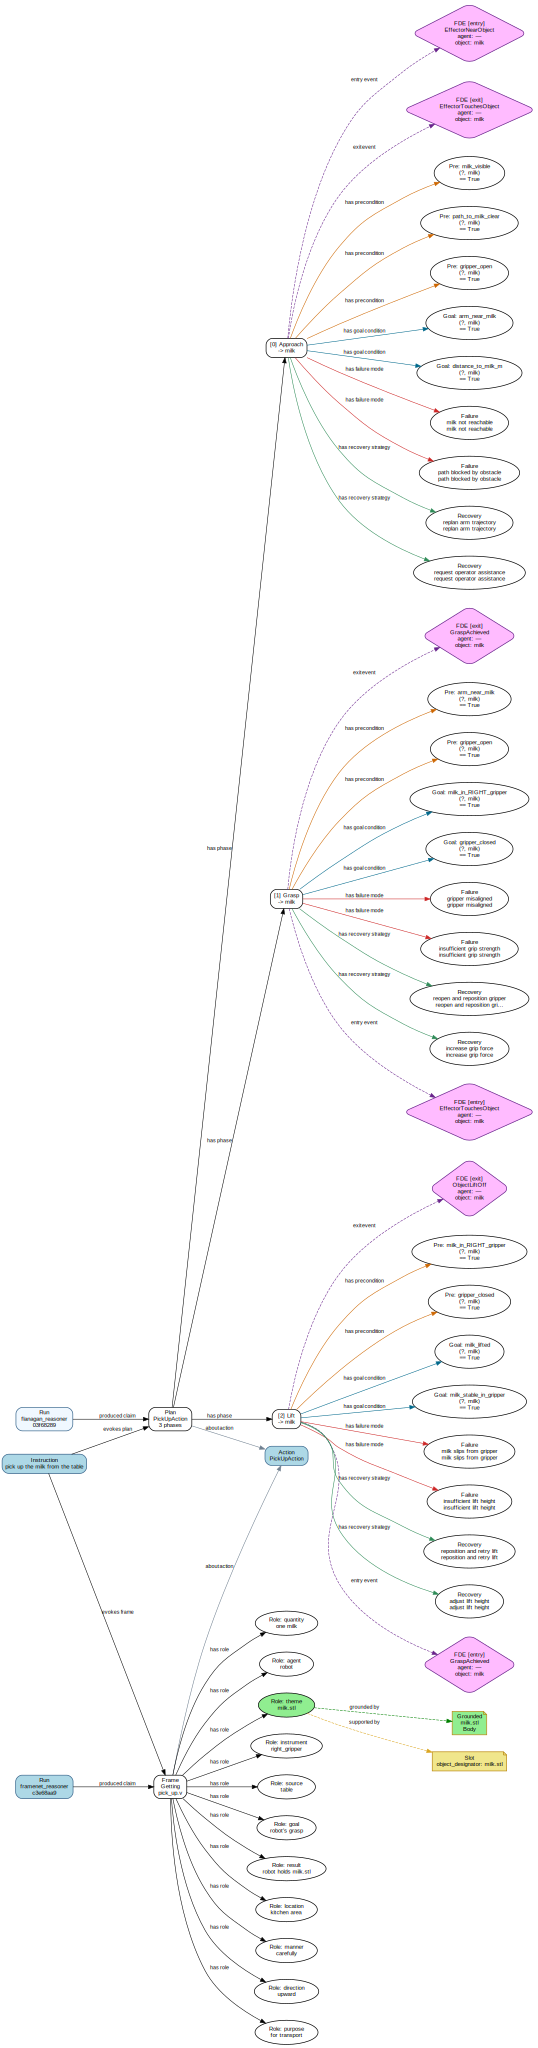

In [6]:
from IPython.display import SVG, display
from llmr.sg_model.adapters import render_graph

rendered_path = render_graph(graph, '/tmp/sg_model_pickup_graph.svg')
print('Rendered to:', rendered_path)
if str(rendered_path).endswith('.svg'):
    display(SVG(filename=str(rendered_path)))